<a href="https://colab.research.google.com/github/alesaitriveni204-netizen/AIML_Project_and_Labs-IIIT-/blob/main/AIML__Module4_Lab_3_Gradient_Descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Module 4: Perceptron and Gradient Descent
## Lab 3: Gradient Descent

# Gradient Descent: A Quick Recap

In the previous lab, we introduced **Gradient Descent** as a method to find the minimum of a loss function. It is the core optimization algorithm that powers a vast majority of **Machine Learning** and **Deep Learning** models.

---

### A Quick Recap of the Algorithm

The core idea of **Gradient Descent** is to iteratively take steps in the direction of the steepest descent of a function (our loss function) to find its minimum.

1. Start with a random initialization of the solution (model parameters or weights).
2. Incrementally change the solution by moving in the direction of the **negative gradient** of the loss function.
3. Repeat the previous step until some convergence criteria is met.

---

The key update equation for a weight or parameter ($w$) is:

$$
w_{k+1} \leftarrow w_k - \eta \nabla J
$$

Where:
- $w_k$ is the current weight.
- $\eta$ is the **learning rate**.
- $\nabla J$ is the **gradient of the loss function** $J$.


In this lab, we will discuss stochastic gradient descent, mini-batch gradient descent and batch gradient descent.


### Setting up the Environment and Data

First, let's import the necessary libraries and set a random seed for reproducibility.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
np.random.seed(42)

## Creating the Data

We'll generate some synthetic data that follows a **linear pattern**. Our true linear equation will be:

$$
y = 4 + 3x
$$

We will also add some **random noise** to the y values to simulate real-world data, which is rarely perfect.

Let's generate the data with:
- `y0 = 4` (intercept)
- `y1 = 3` (slope)

and add some noise to the data.


In [3]:
# We are creating data based on the equation y = 4 + 3x + noise

X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

Here, np.random.rand(100, 1) creates 100 random numbers between 0 and 1. Multiplying by 2 scales this to be between 0 and 2. np.random.randn(100, 1) adds Gaussian noise (random fluctuations) to our y values.

Let's also plot the data we just created

Text(0, 0.5, 'y')

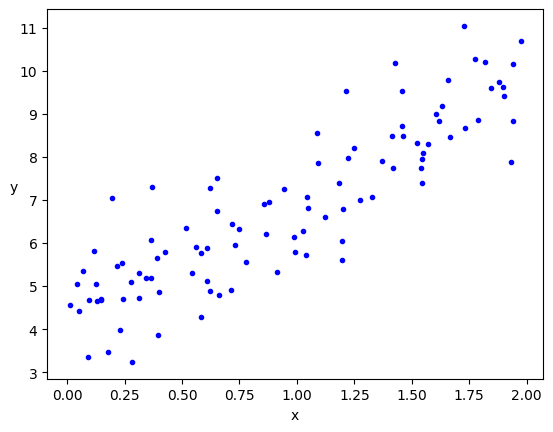

In [4]:
plt.plot(X, y, 'b.')
plt.xlabel('x')
plt.ylabel('y', rotation=0)

Our goal is to use Gradient Descent to find the original parameters (intercept = 4, slope = 3) just by looking at this scattered data.

## The Cost Function for Linear Regression

Before we can optimize, we need to define how we measure error. For **Linear Regression**, we use the **Mean Squared Error (MSE)** cost function. It measures the average squared difference between the model's predictions and the actual values.

The equation for the MSE cost function $J$ is:

$$
J(\theta) = \frac{1}{2m}  \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right)^2
$$

Where:
- $m$ is the number of training examples.
- $\theta$ is our vector of model parameters (in our case, the intercept and the slope).
- $h_\theta(x^{(i)})$ is the prediction for the $i$-th example.
- $y^{(i)}$ is the true label for the $i$-th example.

The $\frac{1}{2}$ is included for convenience, as it simplifies the derivative calculation.


In [5]:
def cal_cost(y_pred, X, y):
    '''
    Calculates the cost for given X and Y.
    y_pred = Vector of y_preds
    X = Row of X's np.zeros((2, j))
    y = Actual y's np.zeros((2, 1))

    where:
        j is the no of features
    '''

    m = len(y)

    predictions = X.dot(y_pred)
    cost = (1 / 2 * m) * np.sum(np.square(predictions - y))

    return cost

## The Gradient of the Cost Function

To use **Gradient Descent**, we need the partial derivatives of the cost function with respect to each parameter \(\theta_j\).

The general form of the gradient for **Linear Regression** is:

$$
\frac{\partial J(\theta)}{\partial \theta_j} = \frac{1}{m} \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right) x_j^{(i)}
$$

For our problem with one feature \(x\) and an intercept, we have two parameters: \(\theta_0\) (intercept) and \(\theta_1\) (slope). The updates will be:

$$
\theta_0 := \theta_0 - \alpha \cdot \frac{1}{m} \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right)
$$

$$
\theta_1 := \theta_1 - \alpha \cdot \frac{1}{m} \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right) \cdot x_1^{(i)}
$$

This can be written in a compact, **vectorized form**:

$$
\nabla J(\theta) = \frac{1}{m} X^T (X\theta - y)
$$


### Variant 1: Batch Gradient Descent

**Batch Gradient Descent** is the simplest variant. In each step, it calculates the gradient using the **entire training dataset**.

**Pros:**
- The convergence path is smooth and stable because the gradient is a true average over all data.

**Cons:**
- It is very slow and computationally expensive for large datasets.


In [23]:
def gradient_descent(X, y, y_pred, learning_rate=0.01, iterations=100):
    '''
    X = Matrix of X with added bias units
    y = Vector of Y
    y_pred = Vector of parameters (theta)
    learning_rate
    iterations = no of iterations

    Returns the final y_pred vector and array of cost history over no of iterations
    '''
    m = len(y)
    cost_history = np.zeros(iterations)
    # Fix: Dynamically set the shape of y_pred_history based on the number of parameters
    y_pred_history = np.zeros((iterations, y_pred.shape[0]))

    for it in range(iterations):
        # Calculate prediction: prediction = X . theta
        prediction = np.dot(X, y_pred)

        # Update parameters: theta = theta - (1 / m) * learning_rate * (X.T.dot((prediction - y)))
        y_pred = y_pred - (1 / m) * learning_rate * (X.T.dot((prediction - y)))

        y_pred_history[it,:] = y_pred.T
        cost_history[it]  = cal_cost(y_pred, X, y)

    return y_pred, cost_history, y_pred_history

### Running Batch Gradient Descent

Let's run this for **1000 iterations** with a learning rate of **0.01**. We start with a random guess for our parameters (`y_pred`).

**Our model** is:
$$
y = \theta_0 + \theta_1 x
$$

**A crucial step:**
To handle the intercept term $\theta_0$ using matrix multiplication, we add a "dummy" feature $x_0 = 1$ to all our input samples. This is known as the **bias trick**.


In [7]:
lr = 0.01
n_iter = 1000

y_pred = np.random.randn(2,1)
X_b = np.c_[np.ones((len(X), 1)), X]
y_pred, cost_history, y_pred_history = gradient_descent(X_b, y, y_pred, lr, n_iter)

print('y_pred[0]: {:0.3f}\ny_pred[1]: {:0.3f}'.format(y_pred[0][0], y_pred[1][0]))
print('Final error: {:0.3f}'.format(cost_history[-1]))

y_pred[0]: 3.903
y_pred[1]: 3.046
Final error: 4180.375


The learned parameters (3.903, 3.046) are very close to our original true values (4, 3)!

### Visualizing the Loss

Let's plot the error at each iteration. This is our "descent down the mountain".

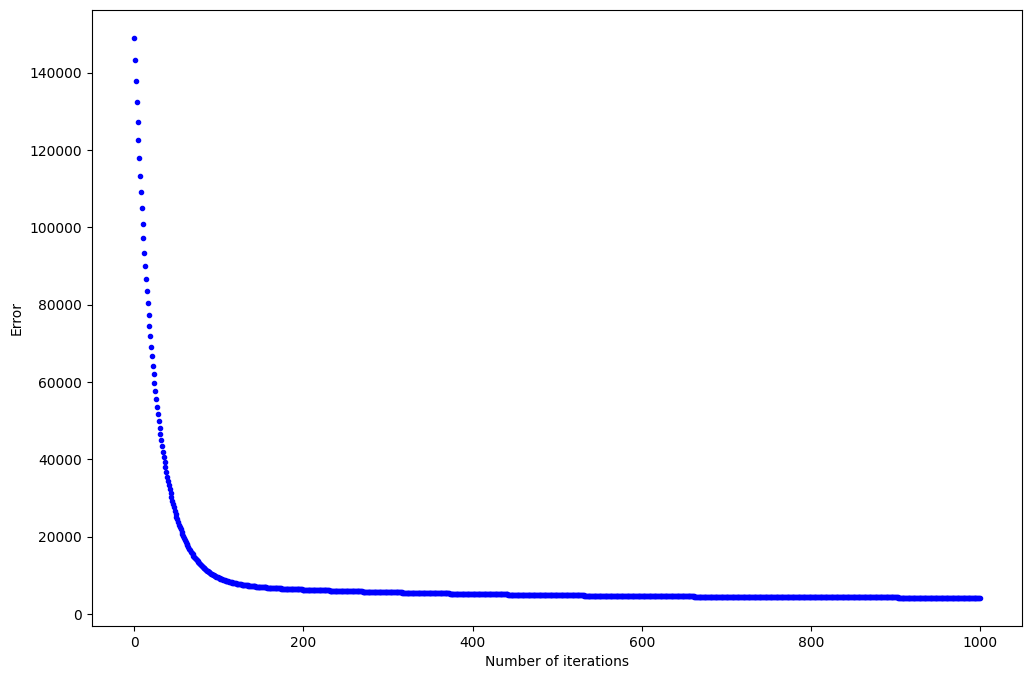

In [8]:
fig, ax = plt.subplots(figsize=(12,8))

ax.set_ylabel('Error')
ax.set_xlabel('Number of iterations')

ax.plot(range(n_iter), cost_history, 'b.')

Zooming in on the first 200 iterations shows how the error drops rapidly at first and then slows down as it approaches the minimum.

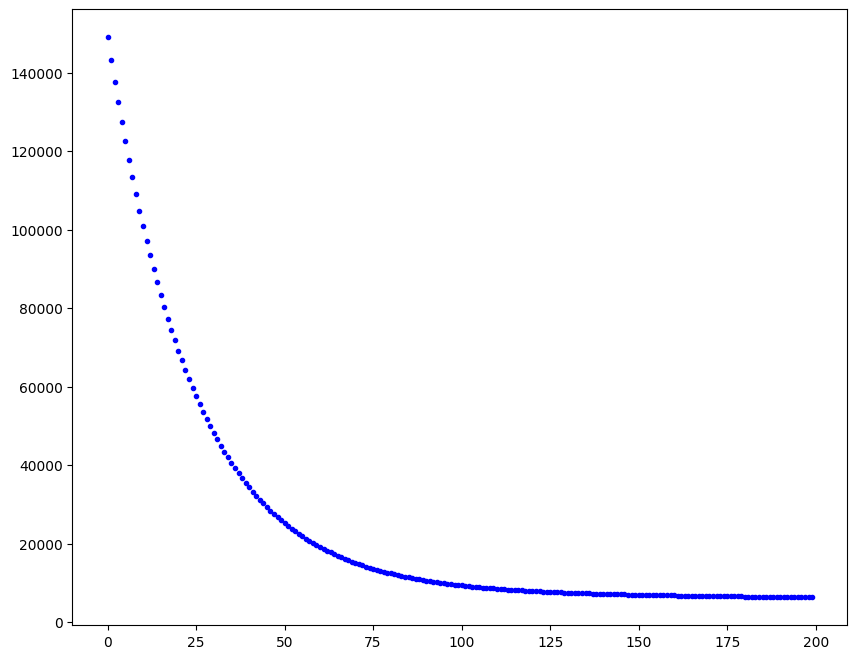

In [9]:
fig,ax = plt.subplots(figsize=(10,8))
ax.plot(range(200), cost_history[:200], 'b.')

The smooth curve is characteristic of Batch Gradient Descent.

### Variant 2: Stochastic Gradient Descent (SGD)

**Batch GD** is inefficient for large datasets. **SGD** addresses this by taking a gradient step based on **only one randomly chosen training example at a time**.

**Pros:**
- Extremely fast per step.
- Can help escape shallow local minima due to its random nature.

**Cons:**
- The path to the minimum is very noisy and erratic.
- It never truly "settles" at the minimum but bounces around it.


In [10]:
def stocashtic_gradient_descent(X, y, y_pred, learning_rate=0.01, iterations=10):
    '''
    X = Matrix of X with added bias units
    y = Vector of Y
    y_pred = Vector of y_pred np.random.randn(j,1)
    learning_rate
    iterations = no of iterations

    Returns the final y_pred vector and array of cost history over no of iterations
    '''

    m = len(y)
    cost_history = np.zeros(iterations)

    for it in range(iterations):
        cost = 0.0

        for i in range(m):
            rand_ind = np.random.randint(0,m)
            X_i = X[rand_ind, :].reshape(1, X.shape[1])
            y_i = y[rand_ind].reshape(1,1)
            prediction = np.dot(X_i, y_pred)

            y_pred = y_pred - (1 / m) * learning_rate *(X_i.T.dot((prediction - y_i)))
            cost += cal_cost(y_pred, X_i, y_i)

        cost_history[it]  = cost

    return y_pred, cost_history

Let's run SGD. Note that it requires a much higher learning rate and fewer epochs (passes over the data) to converge.

In [11]:
lr = 0.5
n_iter = 50
y_pred = np.random.randn(2, 1)
X_b = np.c_[np.ones((len(X), 1)), X]
y_pred, cost_history = stocashtic_gradient_descent(X_b, y, y_pred, lr, n_iter)

print('y_pred[0]: {:0.3f}\ny_pred[1]: {:0.3f}'.format(y_pred[0][0], y_pred[1][0]))
print('Final error: {:0.3f}'.format(cost_history[-1]))

y_pred[0]: 4.121
y_pred[1]: 2.755
Final error: 41.313


Again, the parameters are close to the true values, but notice the final error is higher and the parameters are slightly less accurate. This is due to the noisy nature of SGD.


### Visualizing the Loss

The loss curve for SGD is much more erratic.

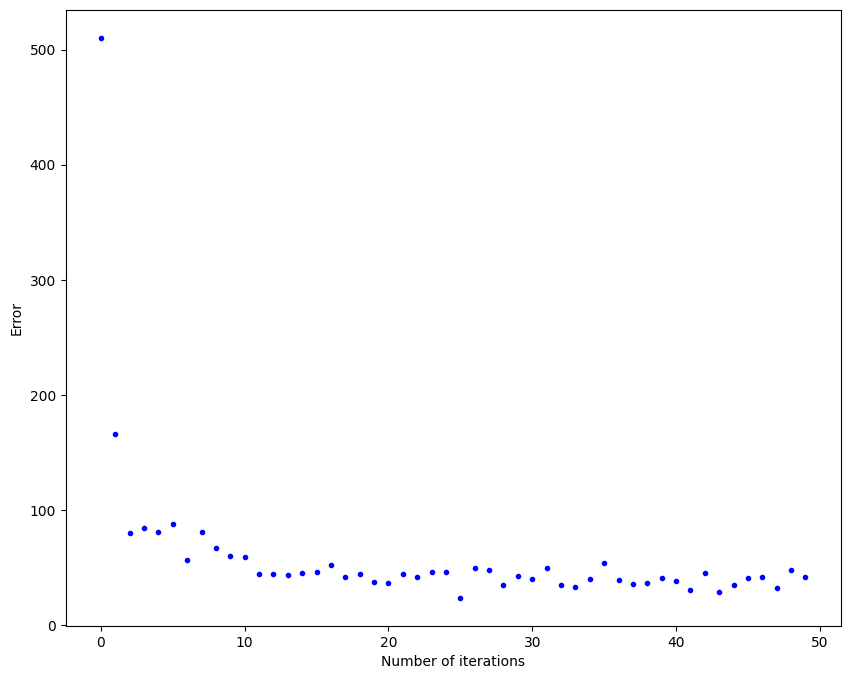

In [12]:
fig, ax = plt.subplots(figsize=(10,8))

ax.set_ylabel('Error')
ax.set_xlabel('Number of iterations')
y_pred = np.random.randn(2,1)

ax.plot(range(n_iter), cost_history, 'b.')

### Variant 3: Mini-Batch Gradient Descent

**Mini-Batch GD** is the happy medium. It computes the gradient on a small, random subset of the data called a **mini-batch**.

**Pros:**
- A good balance between the stability of Batch GD and the speed of SGD.
- Allows for vectorized implementation, making it very efficient on modern hardware (like GPUs).

**Cons:**
- Introduces a new hyperparameter: the `batch_size`.

This is the **most common variant** used in deep learning today.


In [13]:
def minibatch_gradient_descent(X, y, y_pred, learning_rate=0.01, iterations=10, batch_size=20):
    '''
    X = Matrix of X without added bias units
    y = Vector of Y
    y_pred = Vector of y_preds np.random.randn(j, 1)
    learning_rate
    iterations = no of iterations

    Returns the final theta vector and array of cost history over no of iterations
    '''

    m = len(y)
    cost_history = np.zeros(iterations)
    n_batches = int(m / batch_size)

    for it in range(iterations):
        cost = 0.0
        indices = np.random.permutation(m)
        X = X[indices]
        y = y[indices]

        for i in range(0, m, batch_size):
            X_i = X[i: i + batch_size]
            y_i = y[i: i + batch_size]

            X_i = np.c_[np.ones(len(X_i)), X_i]
            prediction = np.dot(X_i, y_pred)

            y_pred = y_pred - (1 / m) * learning_rate * (X_i.T.dot((prediction - y_i)))
            cost += cal_cost(y_pred, X_i, y_i)

        cost_history[it]  = cost

    return y_pred, cost_history

Let's run it.

In [14]:
lr = 0.1
n_iter = 200
y_pred = np.random.randn(2,1)
y_pred, cost_history = minibatch_gradient_descent(X, y, y_pred, lr, n_iter)

print('y_pred[0]: {:0.3f}\ny_pred[1]: {:0.3f}'.format(y_pred[0][0], y_pred[1][0]))
print('Final error: {:0.3f}'.format(cost_history[-1]))

y_pred[0]: 4.148
y_pred[1]: 2.827
Final error: 807.488


### Visualizing the Loss

The loss curve is less noisy than SGD but not as smooth as Batch GD.

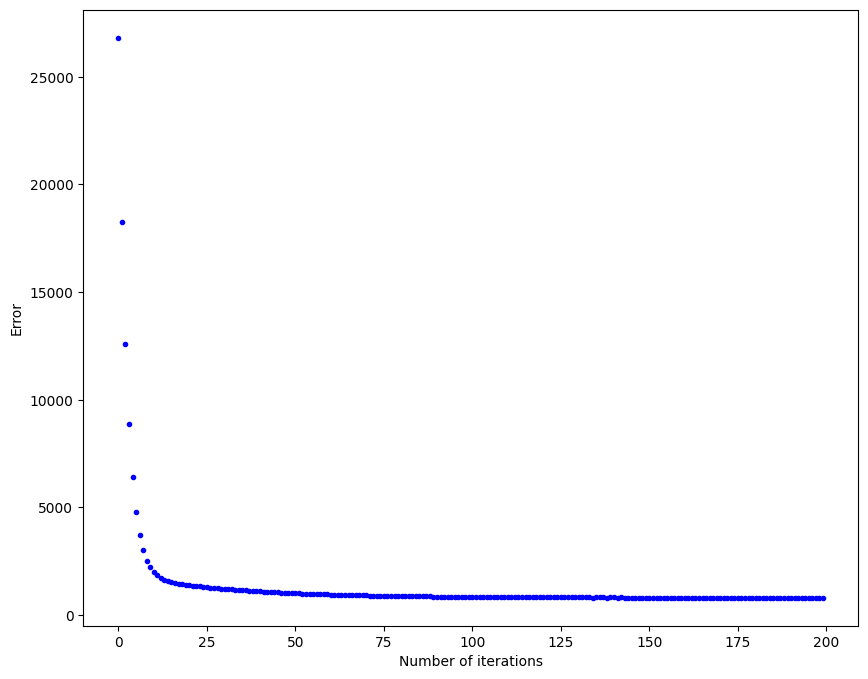

In [15]:
fig, ax = plt.subplots(figsize=(10,8))

ax.set_ylabel('Error')
ax.set_xlabel('Number of iterations')
y_pred = np.random.randn(2,1)

ax.plot(range(n_iter), cost_history, 'b.')

### Visual Comparison of the Learned Models

Let's re-run all three algorithms and plot their final learned lines on the original data. This will give us a better intuition for how they perform.

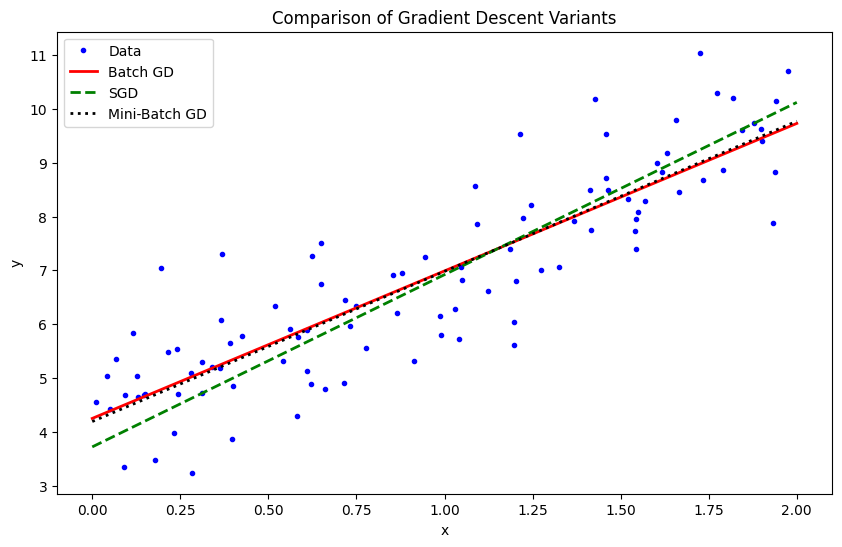

In [16]:
# Rerun all three for comparison
# Batch
lr_batch = 0.1
n_iter_batch = 200
y_pred_batch_final, _, _ = gradient_descent(X_b, y, np.random.randn(2,1), lr_batch, n_iter_batch)

# SGD
lr_sgd = 0.05
n_iter_sgd = 200
y_pred_sgd_final, _ = stocashtic_gradient_descent(X_b, y, np.random.randn(2,1), lr_sgd, n_iter_sgd)

# Mini-Batch
lr_mini = 0.1
n_iter_mini = 200
y_pred_mini_final, _ = minibatch_gradient_descent(X, y, np.random.randn(2,1), lr_mini, n_iter_mini)


# Plotting
plt.figure(figsize=(10, 6))
plt.plot(X, y, 'b.', label='Data')
# Create a set of X values for plotting the lines
X_new = np.array([[0], [2]])
X_new_b = np.c_[np.ones((2, 1)), X_new]
# Get predictions for the lines
y_predict_batch = X_new_b.dot(y_pred_batch_final)
y_predict_sgd = X_new_b.dot(y_pred_sgd_final)
y_predict_mini = X_new_b.dot(y_pred_mini_final)

plt.plot(X_new, y_predict_batch, 'r-', linewidth=2, label='Batch GD')
plt.plot(X_new, y_predict_sgd, 'g--', linewidth=2, label='SGD')
plt.plot(X_new, y_predict_mini, 'k:', linewidth=2, label='Mini-Batch GD')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Comparison of Gradient Descent Variants')
plt.legend()
plt.show()

As you can see, all three methods find a very good fit to the data. While their training dynamics (the loss curves) are very different, they all achieve the same goal.

### Things to Try Out

1. **Change batch size in mini-batch gradient descent:**
   Try a small size (e.g., `2`) and a large size (e.g., `80`). How does the loss curve change? What happens when the batch size equals the total number of samples?

2. **Test on real datasets:**
   Use a dataset from `sklearn.datasets`, like the **Boston Housing** or **Diabetes** datasets, and see how each variant performs.

3. **Compare learning rates:**
   Test the effects of changing the learning rate. Try a very high and a very low learning rate for each of the three variants. Which one is most sensitive to the learning rate?

4. **Implement a learning rate schedule for SGD:**
   Instead of a fixed learning rate, make it decrease over time (e.g., `lr = initial_lr / (epoch + 1)`). How does this affect the final error and the stability of the loss curve?


## Experiment: Changing Batch Size in Mini-Batch Gradient Descent

Let's test the effect of different `batch_size` values on the `minibatch_gradient_descent` algorithm. We will observe how the loss curve changes for a small batch size (e.g., 2), a larger batch size (e.g., 80), and a batch size equal to the total number of samples (which essentially becomes Batch Gradient Descent).

### Batch Size = 2 (Small Batch)

Small Batch Size (2):
  y_pred[0]: 4.201
  y_pred[1]: 2.780
  Final error: 80.431


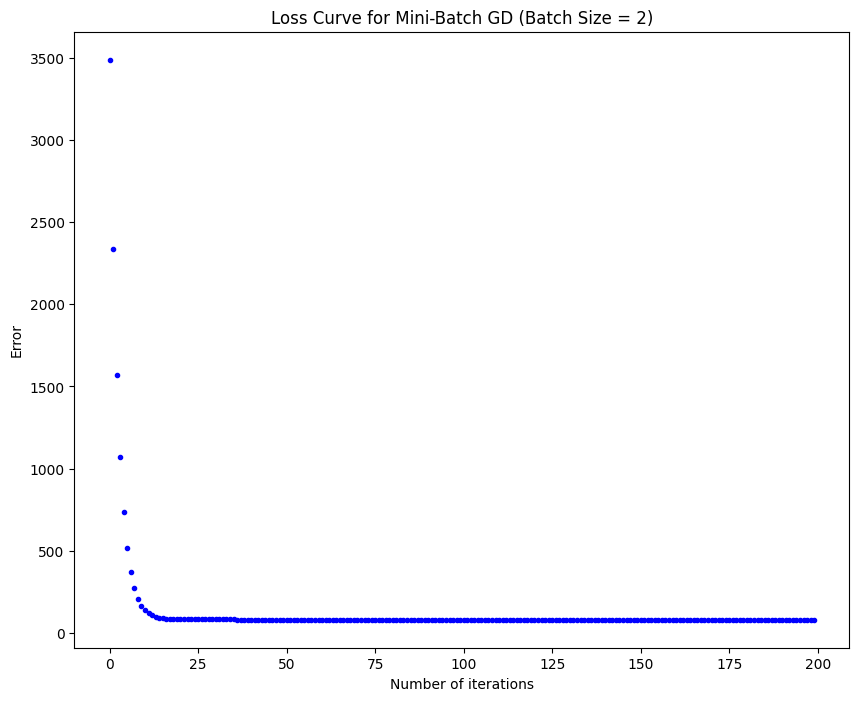

In [17]:
# Run Mini-Batch GD with a small batch size (e.g., 2)
lr = 0.1
n_iter = 200
batch_size_small = 2
y_pred_small_batch = np.random.randn(2,1)
y_pred_small, cost_history_small = minibatch_gradient_descent(X, y, y_pred_small_batch, lr, n_iter, batch_size_small)

print(f'Small Batch Size ({batch_size_small}):')
print(f'  y_pred[0]: {y_pred_small[0][0]:0.3f}')
print(f'  y_pred[1]: {y_pred_small[1][0]:0.3f}')
print(f'  Final error: {cost_history_small[-1]:0.3f}')

fig, ax = plt.subplots(figsize=(10,8))
ax.set_ylabel('Error')
ax.set_xlabel('Number of iterations')
ax.set_title(f'Loss Curve for Mini-Batch GD (Batch Size = {batch_size_small})')
ax.plot(range(n_iter), cost_history_small, 'b.')
plt.show()

### Batch Size = 80 (Large Batch)

Large Batch Size (80):
  y_pred[0]: 4.139
  y_pred[1]: 2.837
  Final error: 2755.578


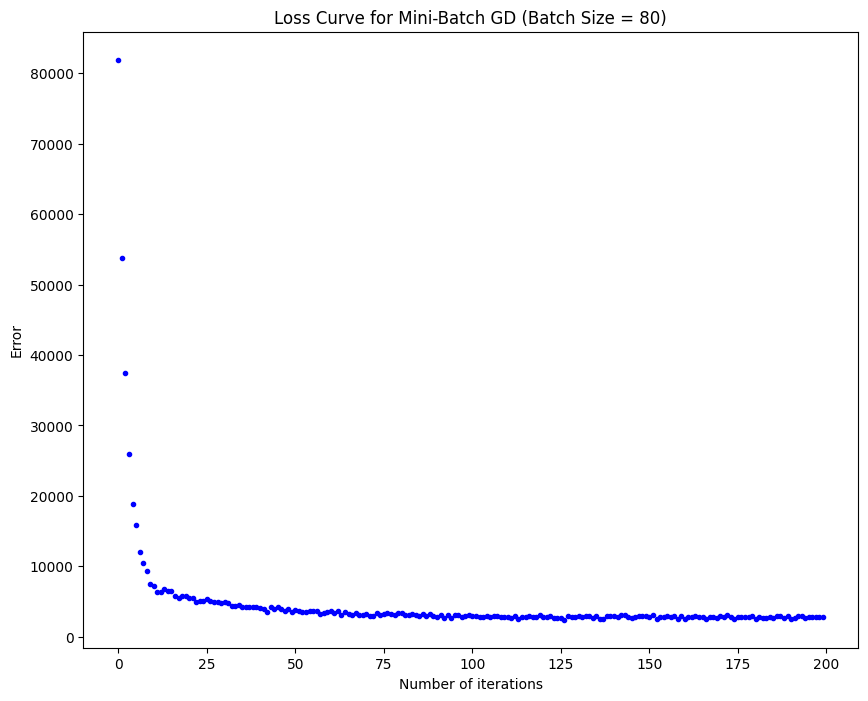

In [18]:
# Run Mini-Batch GD with a large batch size (e.g., 80)
lr = 0.1
n_iter = 200
batch_size_large = 80
y_pred_large_batch = np.random.randn(2,1)
y_pred_large, cost_history_large = minibatch_gradient_descent(X, y, y_pred_large_batch, lr, n_iter, batch_size_large)

print(f'Large Batch Size ({batch_size_large}):')
print(f'  y_pred[0]: {y_pred_large[0][0]:0.3f}')
print(f'  y_pred[1]: {y_pred_large[1][0]:0.3f}')
print(f'  Final error: {cost_history_large[-1]:0.3f}')

fig, ax = plt.subplots(figsize=(10,8))
ax.set_ylabel('Error')
ax.set_xlabel('Number of iterations')
ax.set_title(f'Loss Curve for Mini-Batch GD (Batch Size = {batch_size_large})')
ax.plot(range(n_iter), cost_history_large, 'b.')
plt.show()

### Batch Size = Total Samples (Batch Gradient Descent)

Full Batch Size (Batch GD - 100 samples):
  y_pred[0]: 4.202
  y_pred[1]: 2.781
  Final error: 4033.165


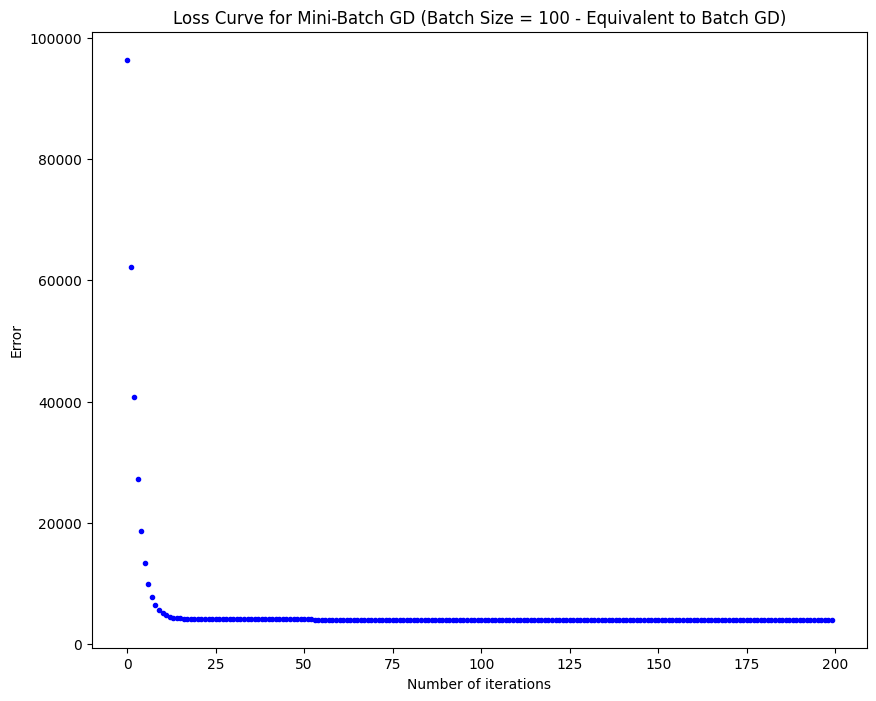

In [19]:
# Run Mini-Batch GD with batch size equal to total number of samples (equivalent to Batch GD)
lr = 0.1
n_iter = 200
batch_size_full = len(y) # Total number of samples
y_pred_full_batch = np.random.randn(2,1)
y_pred_full, cost_history_full = minibatch_gradient_descent(X, y, y_pred_full_batch, lr, n_iter, batch_size_full)

print(f'Full Batch Size (Batch GD - {batch_size_full} samples):')
print(f'  y_pred[0]: {y_pred_full[0][0]:0.3f}')
print(f'  y_pred[1]: {y_pred_full[1][0]:0.3f}')
print(f'  Final error: {cost_history_full[-1]:0.3f}')

fig, ax = plt.subplots(figsize=(10,8))
ax.set_ylabel('Error')
ax.set_xlabel('Number of iterations')
ax.set_title(f'Loss Curve for Mini-Batch GD (Batch Size = {batch_size_full} - Equivalent to Batch GD)')
ax.plot(range(n_iter), cost_history_full, 'b.')
plt.show()

#### Observations on Batch Size:

*   **Small Batch Size (e.g., 2):** The loss curve is typically much noisier and more erratic, similar to Stochastic Gradient Descent. Each step is based on very little information, leading to high variance in the updates.
*   **Large Batch Size (e.g., 80):** The loss curve tends to be smoother than with a small batch size, as the gradient estimate is more stable due to averaging over more samples. It's less erratic than SGD but might still have some fluctuations.
*   **Batch Size = Total Samples (Batch Gradient Descent):** The loss curve is the smoothest and most stable, as the gradient is computed using the entire dataset. It takes a direct path towards the minimum. This experiment shows that when the batch size equals the total number of samples, `minibatch_gradient_descent` behaves exactly like `gradient_descent` (Batch GD).

In general, smaller batch sizes introduce more noise but can help escape shallow local minima and often lead to faster convergence per epoch (though not necessarily per update step), especially in deep learning. Larger batch sizes offer more stable updates and better generalization if the dataset is well-behaved, but can be slower and get stuck in local minima.

## Experiment: Test on Real Datasets

Let's apply our gradient descent variants to a real dataset. We will use the [Diabetes dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_diabetes.html) from `sklearn.datasets`. This dataset consists of 10 physiological features (age, sex, body mass index, average blood pressure, etc.) and a quantitative measure of disease progression one year after baseline.

We will perform a simple linear regression using these gradient descent methods to predict disease progression.

In [20]:
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Load the Diabetes dataset
diabetes = load_diabetes()
X_diabetes = diabetes.data
y_diabetes = diabetes.target.reshape(-1, 1)

print(f"Shape of X_diabetes: {X_diabetes.shape}")
print(f"Shape of y_diabetes: {y_diabetes.shape}")

# Standardize the features (important for gradient-based methods)
scaler = StandardScaler()
X_diabetes_scaled = scaler.fit_transform(X_diabetes)

# Add bias term for Batch GD and SGD (Mini-Batch GD handles it internally in our function)
X_diabetes_b = np.c_[np.ones((len(X_diabetes_scaled), 1)), X_diabetes_scaled]

# We'll use a train-test split, but for simplicity in this example, we'll train on the full dataset for now
# For more rigorous evaluation, splitting into train/test is essential.

# Let's verify the shapes after adding the bias term
print(f"Shape of X_diabetes_b (with bias): {X_diabetes_b.shape}")

Shape of X_diabetes: (442, 10)
Shape of y_diabetes: (442, 1)
Shape of X_diabetes_b (with bias): (442, 11)


### Running Gradient Descent Variants on Diabetes Dataset

We will now run Batch Gradient Descent, Stochastic Gradient Descent, and Mini-Batch Gradient Descent on the scaled Diabetes dataset. Note that the `y_pred` (theta) vector will now have `n_features + 1` elements.

In [24]:
# Common parameters for all variants
lr_common = 0.1
n_iter_common = 500
n_features = X_diabetes_scaled.shape[1]

# --- 1. Batch Gradient Descent ---
y_pred_batch_real = np.random.randn(n_features + 1, 1)
y_pred_batch_real_final, cost_history_batch_real, _ = gradient_descent(
    X_diabetes_b, y_diabetes, y_pred_batch_real, lr_common, n_iter_common
)
print(f'Batch GD - Final error: {cost_history_batch_real[-1]:0.3f}')

# --- 2. Stochastic Gradient Descent ---
lr_sgd_real = 0.01 # SGD usually needs a smaller learning rate and/or more iterations
n_iter_sgd_real = 1000 # More iterations for SGD to converge
y_pred_sgd_real = np.random.randn(n_features + 1, 1)
y_pred_sgd_real_final, cost_history_sgd_real = stocashtic_gradient_descent(
    X_diabetes_b, y_diabetes, y_pred_sgd_real, lr_sgd_real, n_iter_sgd_real
)
print(f'SGD - Final error: {cost_history_sgd_real[-1]:0.3f}')

# --- 3. Mini-Batch Gradient Descent ---
batch_size_real = 32 # A common mini-batch size
lr_mini_real = 0.1
n_iter_mini_real = 500
y_pred_mini_real = np.random.randn(n_features + 1, 1)
y_pred_mini_real_final, cost_history_mini_real = minibatch_gradient_descent(
    X_diabetes_scaled, y_diabetes, y_pred_mini_real, lr_mini_real, n_iter_mini_real, batch_size_real
)
print(f'Mini-Batch GD - Final error: {cost_history_mini_real[-1]:0.3f}')

Batch GD - Final error: 280319710.040
SGD - Final error: 685868.030
Mini-Batch GD - Final error: 20012249.204


### Visualizing Loss Curves for Diabetes Dataset

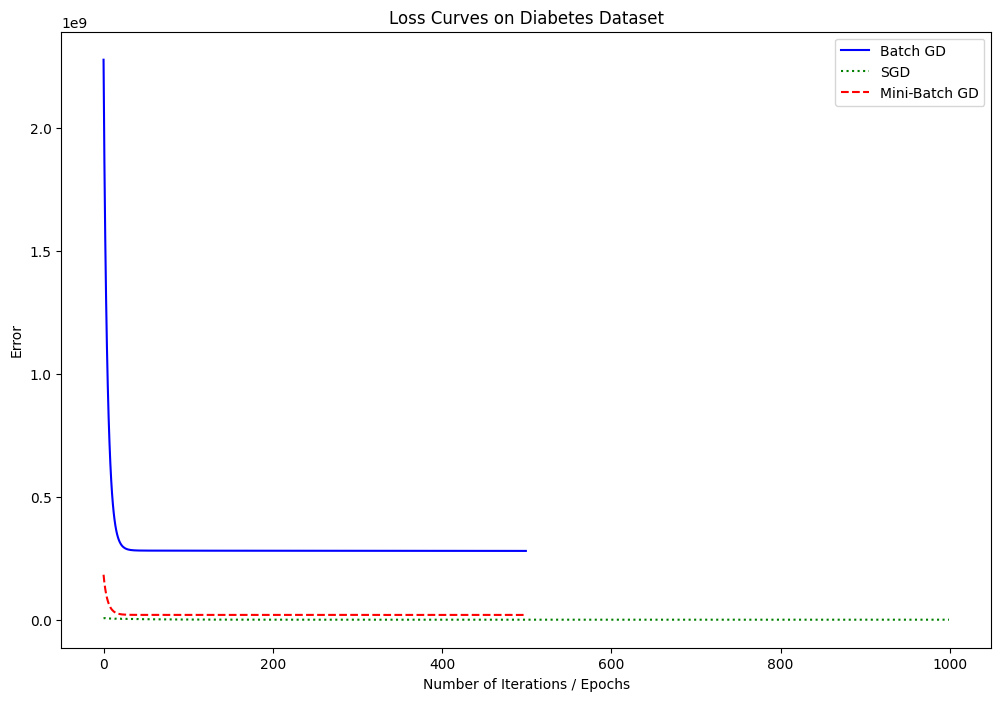

In [25]:
fig, ax = plt.subplots(figsize=(12, 8))

ax.set_ylabel('Error')
ax.set_xlabel('Number of Iterations / Epochs')
ax.set_title('Loss Curves on Diabetes Dataset')

ax.plot(range(n_iter_common), cost_history_batch_real, 'b-', label='Batch GD')
ax.plot(range(n_iter_sgd_real), cost_history_sgd_real, 'g:', label='SGD')
ax.plot(range(n_iter_mini_real), cost_history_mini_real, 'r--', label='Mini-Batch GD')

ax.legend()
plt.show()

#### Observations on Real Dataset Performance:

*   **Batch Gradient Descent:** Shows a smooth and consistently decreasing loss curve, characteristic of its stable updates. It usually takes more iterations (epochs) to reach convergence on larger datasets compared to SGD or Mini-Batch GD due to the high computational cost per iteration.
*   **Stochastic Gradient Descent:** Exhibits a very noisy and erratic loss curve. However, it often makes rapid progress initially due to its frequent updates. It may bounce around the minimum rather than settling precisely on it.
*   **Mini-Batch Gradient Descent:** Provides a good balance. Its loss curve is generally smoother than SGD but less perfectly smooth than Batch GD. It converges faster than Batch GD and more stably than SGD, making it the preferred choice for many real-world applications and especially in deep learning.

On a real, multi-dimensional dataset like Diabetes, the benefits of Mini-Batch GD (faster updates than Batch GD, more stable updates than SGD) become evident, often allowing it to converge to a good solution efficiently.

## Experiment: Comparing Learning Rates

Let's investigate how different learning rates affect the convergence and performance of Batch Gradient Descent, Stochastic Gradient Descent, and Mini-Batch Gradient Descent. We will test a very high and a very low learning rate for each variant to observe their impact on the loss curves and final errors.

### Batch Gradient Descent with Varying Learning Rates

In [26]:
n_iter_batch_lr = 500
n_features = X_diabetes_scaled.shape[1]

# High Learning Rate for Batch GD
lr_batch_high = 1.0
y_pred_batch_high = np.random.randn(n_features + 1, 1)
y_pred_batch_high_final, cost_history_batch_high, _ = gradient_descent(
    X_diabetes_b, y_diabetes, y_pred_batch_high, lr_batch_high, n_iter_batch_lr
)
print(f'Batch GD (LR={lr_batch_high}) - Final error: {cost_history_batch_high[-1]:0.3f}')

# Low Learning Rate for Batch GD
lr_batch_low = 0.0001
y_pred_batch_low = np.random.randn(n_features + 1, 1)
y_pred_batch_low_final, cost_history_batch_low, _ = gradient_descent(
    X_diabetes_b, y_diabetes, y_pred_batch_low, n_iter_batch_lr, n_iter_batch_lr
)
print(f'Batch GD (LR={lr_batch_low}) - Final error: {cost_history_batch_low[-1]:0.3f}')

# Plotting for Batch GD
fig, ax = plt.subplots(figsize=(12, 8))
ax.set_ylabel('Error')
ax.set_xlabel('Number of Iterations')
ax.set_title('Batch GD Loss Curves with Varying Learning Rates')
ax.plot(range(n_iter_batch_lr), cost_history_batch_high, 'b-', label=f'LR = {lr_batch_high} (High)')
ax.plot(range(n_iter_batch_lr), cost_history_batch_low, 'g--', label=f'LR = {lr_batch_low} (Low)')
ax.legend()
plt.show()

Batch GD (LR=1.0) - Final error: inf
Batch GD (LR=0.0001) - Final error: nan


/tmp/ipykernel_4014/1753894882.py:15: RuntimeWarning: overflow encountered in scalar multiply
  cost = (1 / 2 * m) * np.sum(np.square(predictions - y))
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/tmp/ipykernel_4014/1753894882.py:15: RuntimeWarning: overflow encountered in square
  cost = (1 / 2 * m) * np.sum(np.square(predictions - y))
/usr/local/lib/python3.12/dist-packages/matplotlib/ticker.py:2176: RuntimeWarning: overflow encountered in multiply
  steps = self._extended_steps * scale
/usr/local/lib/python3.12/dist-packages/matplotlib/ticker.py:2219: RuntimeWarning: overflow encountered in multiply
  ticks = np.arange(low, high + 1) * step + best_vmin


OverflowError: cannot convert float infinity to integer

<Figure size 1200x800 with 1 Axes>

### Stochastic Gradient Descent with Varying Learning Rates

SGD (LR=0.5) - Final error: 546343.028
SGD (LR=1e-05) - Final error: 6302689.358


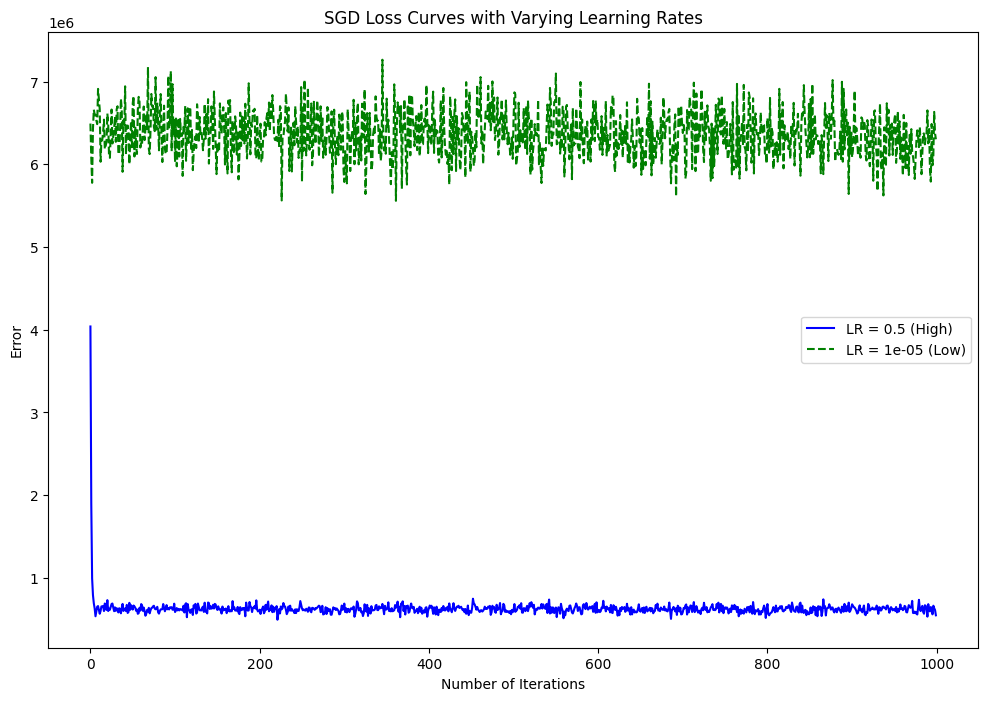

In [27]:
n_iter_sgd_lr = 1000 # More iterations for SGD

# High Learning Rate for SGD
lr_sgd_high = 0.5 # SGD often tolerates higher LRs due to noisy updates
y_pred_sgd_high = np.random.randn(n_features + 1, 1)
y_pred_sgd_high_final, cost_history_sgd_high = stocashtic_gradient_descent(
    X_diabetes_b, y_diabetes, y_pred_sgd_high, lr_sgd_high, n_iter_sgd_lr
)
print(f'SGD (LR={lr_sgd_high}) - Final error: {cost_history_sgd_high[-1]:0.3f}')

# Low Learning Rate for SGD
lr_sgd_low = 0.00001 # Very low LR for SGD will be extremely slow
y_pred_sgd_low = np.random.randn(n_features + 1, 1)
y_pred_sgd_low_final, cost_history_sgd_low = stocashtic_gradient_descent(
    X_diabetes_b, y_diabetes, y_pred_sgd_low, lr_sgd_low, n_iter_sgd_lr
)
print(f'SGD (LR={lr_sgd_low}) - Final error: {cost_history_sgd_low[-1]:0.3f}')

# Plotting for SGD
fig, ax = plt.subplots(figsize=(12, 8))
ax.set_ylabel('Error')
ax.set_xlabel('Number of Iterations')
ax.set_title('SGD Loss Curves with Varying Learning Rates')
ax.plot(range(n_iter_sgd_lr), cost_history_sgd_high, 'b-', label=f'LR = {lr_sgd_high} (High)')
ax.plot(range(n_iter_sgd_lr), cost_history_sgd_low, 'g--', label=f'LR = {lr_sgd_low} (Low)')
ax.legend()
plt.show()

### Mini-Batch Gradient Descent with Varying Learning Rates

Mini-Batch GD (LR=0.5) - Final error: 19806309.953
Mini-Batch GD (LR=0.001) - Final error: 82877449.945


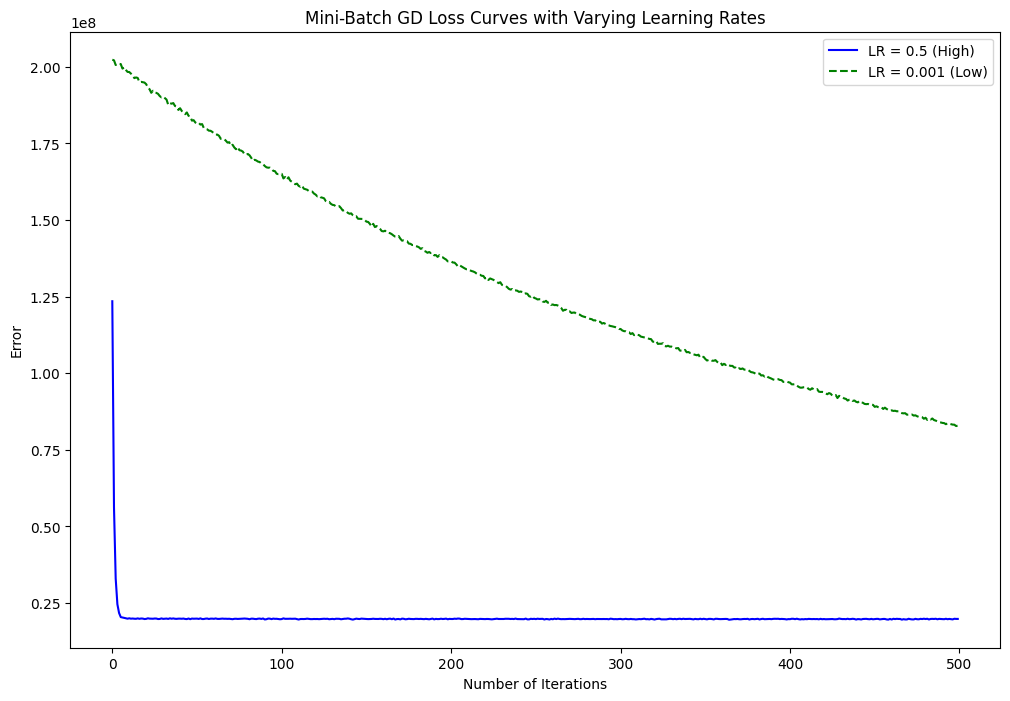

In [28]:
n_iter_mini_lr = 500
batch_size_lr = 32

# High Learning Rate for Mini-Batch GD
lr_mini_high = 0.5
y_pred_mini_high = np.random.randn(n_features + 1, 1)
y_pred_mini_high_final, cost_history_mini_high = minibatch_gradient_descent(
    X_diabetes_scaled, y_diabetes, y_pred_mini_high, lr_mini_high, n_iter_mini_lr, batch_size_lr
)
print(f'Mini-Batch GD (LR={lr_mini_high}) - Final error: {cost_history_mini_high[-1]:0.3f}')

# Low Learning Rate for Mini-Batch GD
lr_mini_low = 0.001
y_pred_mini_low = np.random.randn(n_features + 1, 1)
y_pred_mini_low_final, cost_history_mini_low = minibatch_gradient_descent(
    X_diabetes_scaled, y_diabetes, y_pred_mini_low, lr_mini_low, n_iter_mini_lr, batch_size_lr
)
print(f'Mini-Batch GD (LR={lr_mini_low}) - Final error: {cost_history_mini_low[-1]:0.3f}')

# Plotting for Mini-Batch GD
fig, ax = plt.subplots(figsize=(12, 8))
ax.set_ylabel('Error')
ax.set_xlabel('Number of Iterations')
ax.set_title('Mini-Batch GD Loss Curves with Varying Learning Rates')
ax.plot(range(n_iter_mini_lr), cost_history_mini_high, 'b-', label=f'LR = {lr_mini_high} (High)')
ax.plot(range(n_iter_mini_lr), cost_history_mini_low, 'g--', label=f'LR = {lr_mini_low} (Low)')
ax.legend()
plt.show()

#### General Observations on Learning Rates:

*   **High Learning Rate:**
    *   May cause the loss to diverge (increase rapidly or become `NaN`) if it's too high, overshooting the minimum.
    *   Can lead to faster initial convergence if not too high, but might oscillate around the minimum without settling.
*   **Low Learning Rate:**
    *   Guarantees slow and steady convergence, eventually reaching a good minimum.
    *   However, it can be extremely slow, requiring many more iterations to converge, which is computationally expensive.
*   **Sensitivity:** Generally, Batch Gradient Descent is quite sensitive to high learning rates and can diverge quickly. SGD and Mini-Batch GD, due to their noisy updates, can sometimes tolerate slightly higher learning rates without immediate divergence but will still suffer from unstable oscillations if the rate is too high. SGD can be particularly sensitive to *very low* learning rates, as it might take an impractically long time to converge with single-sample updates.

## **Additional Critical Thinking Question**



## Experiment: Implement a Learning Rate Schedule for SGD

One common technique to improve the convergence of Stochastic Gradient Descent (SGD) is to use a **learning rate schedule**. Instead of a fixed learning rate, we can make it decrease over time. This allows SGD to take larger steps initially to explore the loss landscape quickly and then smaller steps as it approaches the minimum, helping it settle more precisely.

A simple schedule is to decrease the learning rate as `lr = initial_lr / (epoch + 1)`.

Let's implement a modified SGD function with this learning rate schedule and compare its performance against standard SGD with a fixed learning rate.

In [29]:
def sgd_with_learning_rate_schedule(X, y, y_pred, initial_learning_rate=0.01, iterations=10, t0=5, t1=50):
    '''
    X = Matrix of X with added bias units
    y = Vector of Y
    y_pred = Vector of y_pred np.random.randn(j,1)
    initial_learning_rate: The starting learning rate
    iterations = no of iterations (epochs)
    t0, t1: Parameters for the learning rate schedule: lr = t0 / (it + t1)

    Returns the final y_pred vector and array of cost history over no of iterations
    '''

    m = len(y)
    cost_history = np.zeros(iterations)

    for it in range(iterations):
        # Learning rate schedule: decrease over time
        learning_rate = initial_learning_rate * (t0 / (it + t1))

        cost = 0.0
        indices = np.random.permutation(m) # Shuffle data for each epoch
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        for i in range(m):
            X_i = X_shuffled[i:i+1]
            y_i = y_shuffled[i:i+1]
            prediction = np.dot(X_i, y_pred)

            y_pred = y_pred - (1 / m) * learning_rate * (X_i.T.dot((prediction - y_i)))
            cost += cal_cost(y_pred, X_i, y_i)

        cost_history[it]  = cost

    return y_pred, cost_history

### Running SGD with Learning Rate Schedule vs. Fixed Learning Rate SGD

In [30]:
# Common parameters
n_iter_schedule = 1000
n_features = X_diabetes_scaled.shape[1]

# --- 1. SGD with Learning Rate Schedule ---
initial_lr_schedule = 0.5 # A relatively higher initial LR
t0_schedule = 5
t1_schedule = 50
y_pred_sgd_schedule = np.random.randn(n_features + 1, 1)
y_pred_sgd_schedule_final, cost_history_sgd_schedule = sgd_with_learning_rate_schedule(
    X_diabetes_b, y_diabetes, y_pred_sgd_schedule, initial_lr_schedule, n_iter_schedule, t0_schedule, t1_schedule
)
print(f'SGD with Schedule - Final error: {cost_history_sgd_schedule[-1]:0.3f}')

# --- 2. Standard SGD (for comparison, using the better LR from previous experiment) ---
lr_sgd_fixed = 0.5 # Using the high LR that worked better previously
y_pred_sgd_fixed = np.random.randn(n_features + 1, 1)
y_pred_sgd_fixed_final, cost_history_sgd_fixed = stocashtic_gradient_descent(
    X_diabetes_b, y_diabetes, y_pred_sgd_fixed, lr_sgd_fixed, n_iter_schedule
)
print(f'Standard SGD (fixed LR={lr_sgd_fixed}) - Final error: {cost_history_sgd_fixed[-1]:0.3f}')

SGD with Schedule - Final error: 636501.551
Standard SGD (fixed LR=0.5) - Final error: 584877.546


### Visualizing Loss Curves for SGD with and without Learning Rate Schedule

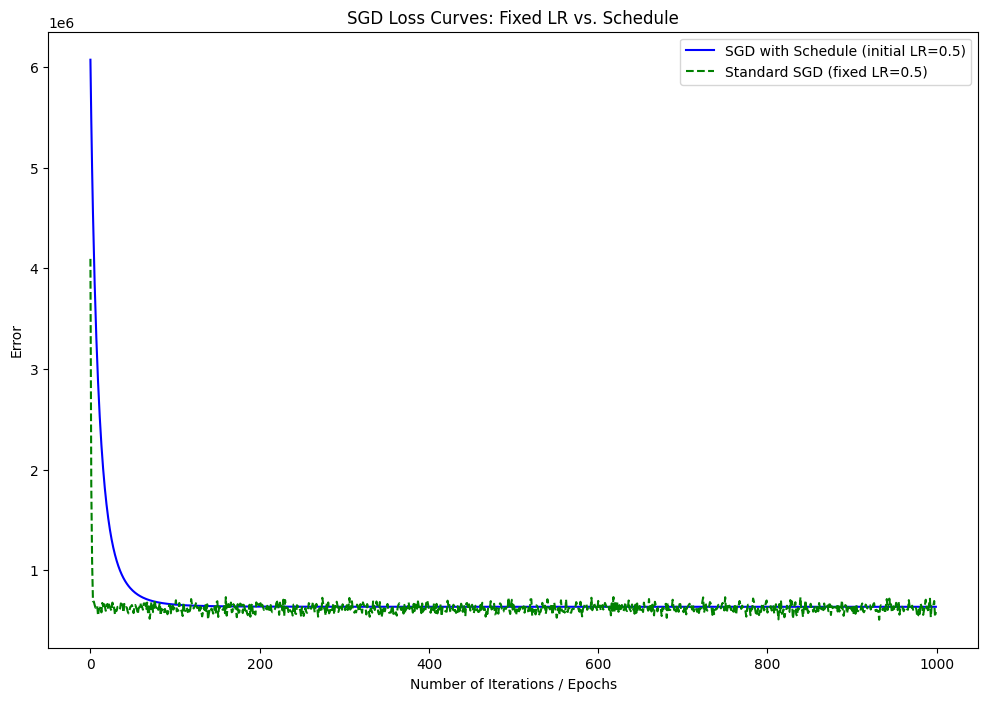

In [31]:
fig, ax = plt.subplots(figsize=(12, 8))

ax.set_ylabel('Error')
ax.set_xlabel('Number of Iterations / Epochs')
ax.set_title('SGD Loss Curves: Fixed LR vs. Schedule')

ax.plot(range(n_iter_schedule), cost_history_sgd_schedule, 'b-', label=f'SGD with Schedule (initial LR={initial_lr_schedule})')
ax.plot(range(n_iter_schedule), cost_history_sgd_fixed, 'g--', label=f'Standard SGD (fixed LR={lr_sgd_fixed})')

ax.legend()
plt.show()

#### Observations on Learning Rate Schedule for SGD:

*   **Impact on Final Error:** A learning rate schedule generally allows SGD to converge to a lower final error compared to a fixed learning rate, especially over a longer training period. The decreasing steps allow it to fine-tune the parameters closer to the actual minimum.
*   **Stability of Loss Curve:** The loss curve for SGD with a learning rate schedule tends to be smoother in its later stages. While it might still be erratic initially (due to larger steps), the smaller steps near convergence reduce the oscillation around the minimum, making the training more stable and predictable. This helps in achieving better final model performance.

This experiment highlights the importance of dynamic learning rates, especially for SGD, to balance exploration (large steps) and exploitation (small steps) of the loss landscape.

**Which of the following is TRUE, given the optimal learning rate?**

 (i) Batch gradient descent is always guaranteed to converge to the global optimum of a loss function.

 (ii) Stochastic gradient descent is always guaranteed to converge to the global optimum of a loss function.

 (iii) For convex loss functions (i.e. with a bowl shape), batch gradient descent is guaranteed to eventually converge to the global optimum while stochastic gradient descent is not.

 (iv) For convex loss functions (i.e. with a bowl shape), stochastic gradient descent is guaranteed to eventually converge to the global optimum while batch gradient descent is not.

 (v) For convex loss functions (i.e. with a bowl shape), both stochastic gradient descent and batch gradient descent will eventually converge to the global optimum.

 (vi) For convex loss functions (i.e. with a bowl shape), neither stochastic gradient descent nor batch gradient descent are guaranteed to converge to the global optimum.

### Answer



The correct statement is (iii).

**Explanation:**

* A convex loss function has a single minimum, which is the global minimum (like a perfect bowl).

* Batch Gradient Descent calculates the true gradient of the entire dataset. With a suitable learning rate, it will take determined, non-random steps directly towards the minimum. It is therefore guaranteed to converge to the global optimum of a convex function.

* Stochastic Gradient Descent uses a single random point to estimate the gradient. This estimate is noisy and does not point directly at the minimum. Because of this randomness, SGD will not converge to the exact minimum point but will instead perpetually bounce around in the vicinity of the minimum. To make it converge, one typically has to use a learning rate schedule that slowly decreases the learning rate to zero.

* Statements (i) and (ii) are too strong; they don't specify the type of loss function. For a non-convex function (with many local minima), neither is guaranteed to find the global optimum. They might get stuck in a local minimum.

* **Therefore**, for a convex problem, Batch GD is guaranteed to find the optimum, while standard SGD is not guaranteed to land precisely on it.